# Attention-side probes

Attention is the only operation in a ViT block that moves information between tokens, so it is where a token-level perturbation should matter most. This notebook reads every attention-side probe the sweeps cover, the placements the pre-registered basis declares and the ones it does not, and asks whether any of them beats PSBD-TM. It follows `scripts/paper/tab_attention.py`: full-depth probes only, the adaptive rate rule, the headline quantile and a floor on the number of models behind a mean. It reads cached JSON only and runs in a few seconds.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cli.compare_detectors import psbd_values
from defenses.decision import HEADLINE_QUANTILE, RECOMMENDED_PLACEMENT
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    HEADLINE_KEY,
    OKABE_ITO,
    bootstrap_ci,
    clearing_cells,
    load_coverage,
    load_declaration,
    load_psbd_metrics,
    mean_or_none,
    placement_words,
)
from scripts.paper._style import TEXT_WIDTH
from scripts.paper.tab_attention import MIN_CELLS, RULE, TPR_KEYS, readings

In [3]:
import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

## Probe means

The generator's own `readings` collects every clearing model's AUROC and its true-positive rates at the 10% and 20% false-positive budgets for each attention probe. Coverage is uneven, since the probes outside the basis were swept on a subset of the panel, so the means in this table are not paired.

In [4]:
declaration = load_declaration("configs/psbd_basis.json")
declared = {entry["id"] for entry in declaration["basis"]}
folders = [cell["folder_name"] for cell in clearing_cells(load_coverage("results"))]
found = readings("results", folders)

probe_rows = []
for placement, values in found.items():
    if len(values["auroc"]) < MIN_CELLS:
        continue
    probe_rows.append(
        {
            "placement": placement,
            "probe": placement_words(placement),
            "in basis": placement in declared,
            "n": len(values["auroc"]),
            "AUROC": mean_or_none(values["auroc"]),
            "TPR@10": mean_or_none(values[TPR_KEYS[0]]),
            "TPR@20": mean_or_none(values[TPR_KEYS[1]]),
        }
    )
probes = (
    pd.DataFrame(probe_rows)
    .sort_values("AUROC", ascending=False)
    .reset_index(drop=True)
)

print(
    f"{len(folders)} clearing models, rule {RULE}, threshold at the {HEADLINE_QUANTILE:.0%} quantile"
)
print(
    f"{len(probes)} attention probes with at least {MIN_CELLS} models, {probes['in basis'].sum()} in the basis"
)
probes.drop(columns="placement").round(3)

71 clearing models, rule adaptive, threshold at the 25% quantile
19 attention probes with at least 5 models, 11 in the basis


,probe,in basis,n,AUROC,TPR@10,TPR@20
0,"token mask, attention input",True,69,0.927,0.766,0.835
1,"token mask, attention output before the add",True,68,0.927,0.793,0.875
2,"noise, attention input after norm",False,19,0.913,0.789,0.867
3,"head mask, attention heads",False,37,0.896,0.743,0.842
4,"channel mask, attention input",True,71,0.883,0.682,0.767
5,"token mask, attention input after norm",False,37,0.876,0.748,0.810
6,"drop path, attention output before the add",False,37,0.872,0.660,0.788
7,"dropout, attention input",True,65,0.859,0.625,0.732
8,"channel mask, attention input after norm",False,37,0.847,0.663,0.767
9,"channel mask, stream after the attention add",False,37,0.835,0.655,0.736


## Paired gaps against PSBD-TM

An unpaired mean over a subset of the panel can differ from a mean over the whole panel only because the subset holds easier models. The paired gap reads each probe against PSBD-TM on exactly the models carrying both, with a bootstrap interval over those models.

In [5]:
reports = {folder: load_psbd_metrics("results", folder) or {} for folder in folders}


def headline_auroc(report, placement):
    block = psbd_values(report, placement, RULE)
    if block is None or block.get(HEADLINE_KEY) is None:
        return None
    return block[HEADLINE_KEY].get("auroc")


gap_rows = []
for placement in probes["placement"]:
    deltas = []
    for report in reports.values():
        probe_auroc = headline_auroc(report, placement)
        recommended_auroc = headline_auroc(report, RECOMMENDED_PLACEMENT)
        if probe_auroc is not None and recommended_auroc is not None:
            deltas.append(probe_auroc - recommended_auroc)
    low, high = bootstrap_ci(deltas, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    gap_rows.append(
        {
            "placement": placement,
            "paired n": len(deltas),
            "gap": mean_or_none(deltas),
            "low": low,
            "high": high,
        }
    )

probes = probes.merge(pd.DataFrame(gap_rows), on="placement")
outside = probes[~probes["in basis"]]
beating = outside[outside["low"] > 0]
print(
    f"probes outside the basis whose paired gap interval sits above 0: {len(beating)}"
)
print(f"largest paired gap outside the basis: {outside['gap'].max():+.3f}")
probes[["probe", "in basis", "paired n", "gap", "low", "high"]].round(3)

probes outside the basis whose paired gap interval sits above 0: 0
largest paired gap outside the basis: -0.071


,probe,in basis,paired n,gap,low,high
0,"token mask, attention input",True,69,0.000,0.000,0.000
1,"token mask, attention output before the add",True,66,-0.002,-0.028,0.027
2,"noise, attention input after norm",False,19,-0.071,-0.136,-0.023
3,"head mask, attention heads",False,37,-0.072,-0.110,-0.032
4,"channel mask, attention input",True,69,-0.046,-0.084,-0.011
5,"token mask, attention input after norm",False,37,-0.092,-0.169,-0.025
6,"drop path, attention output before the add",False,37,-0.096,-0.142,-0.052
7,"dropout, attention input",True,65,-0.076,-0.121,-0.037
8,"channel mask, attention input after norm",False,37,-0.121,-0.182,-0.064
9,"channel mask, stream after the attention add",False,37,-0.133,-0.219,-0.055


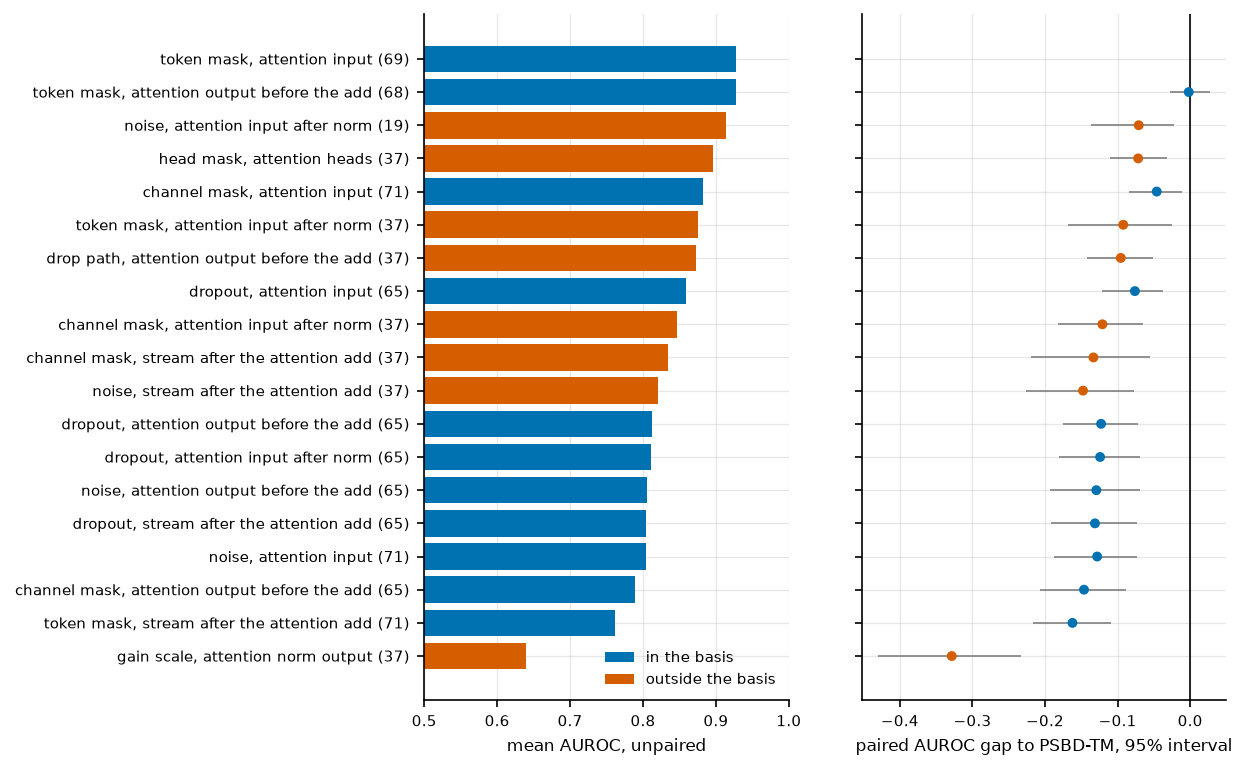

In [6]:
figure, (mean_axis, gap_axis) = plt.subplots(
    1, 2, figsize=(TEXT_WIDTH, 0.26 * len(probes) + 1.0), sharey=True
)
positions = np.arange(len(probes))  # (probes,)
bar_colors = [
    OKABE_ITO[0] if in_basis else OKABE_ITO[1] for in_basis in probes["in basis"]
]

mean_axis.barh(positions, probes["AUROC"], color=bar_colors)
mean_axis.set_yticks(
    positions,
    labels=[f"{probe} ({n})" for probe, n in zip(probes["probe"], probes["n"])],
)
mean_axis.invert_yaxis()
mean_axis.set_xlim(0.5, 1.0)
mean_axis.set_xlabel("mean AUROC, unpaired")
mean_axis.bar(0, 0, color=OKABE_ITO[0], label="in the basis")
mean_axis.bar(0, 0, color=OKABE_ITO[1], label="outside the basis")
mean_axis.legend(loc="lower right")

# The PSBD-TM row is the reference itself, so its gap is 0 by construction and is
# left out of the right panel.
is_reference = (probes["placement"] == RECOMMENDED_PLACEMENT).to_numpy()  # (probes,)
gap_errors = np.vstack(
    [probes["gap"] - probes["low"], probes["high"] - probes["gap"]]
)  # (2, probes)
gap_axis.errorbar(
    probes["gap"][~is_reference],
    positions[~is_reference],
    xerr=gap_errors[:, ~is_reference],
    fmt="none",
    ecolor="gray",
    linewidth=0.8,
)
gap_axis.scatter(
    probes["gap"][~is_reference],
    positions[~is_reference],
    c=np.array(bar_colors)[~is_reference],
    s=14,
    zorder=3,
)
gap_axis.axvline(0.0, color="black", linewidth=0.8)
gap_axis.set_xlabel("paired AUROC gap to PSBD-TM, 95% interval")
plt.show()

## Reading the probes

The left panel is the table the paper prints and the right panel is the comparison that decides it. PSBD-TM sits at the top together with its twin, token masking on the attention branch output before the add. The probes ranked just below them on the left panel were swept on fewer models. Read in pairs, every probe but the twin has its whole interval below 0, so the wider search found no attention probe that matches the pre-registered winner. Noise after the attention norm and head masking are the strongest probes the basis never declared and trail by about the same amount. Gain scaling of the attention norm output is the weakest of all.